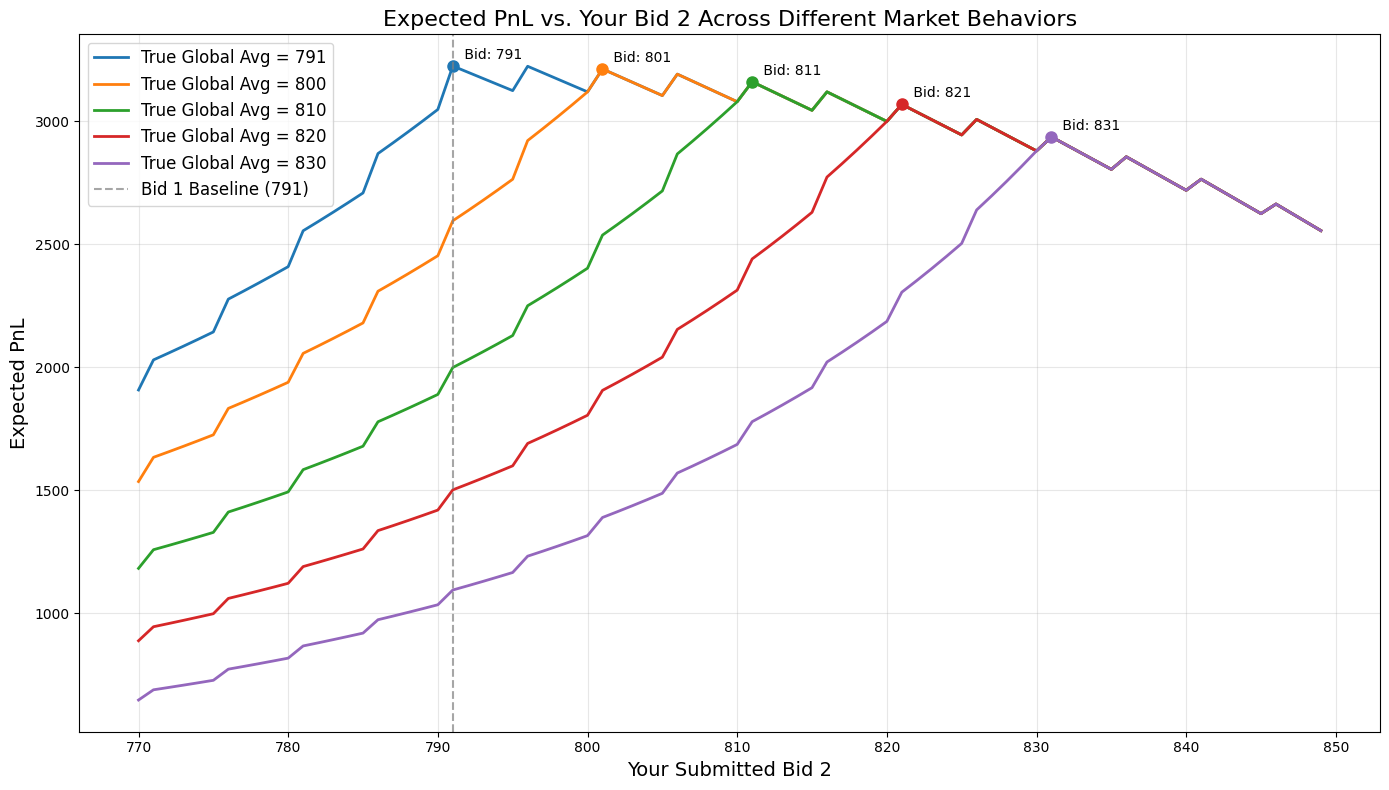

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_bid_2_pnl_array(bids, actual_avg_b2):
    """
    Calculates the Expected PnL for an array of bids given a specific true global average.
    """
    min_reserve = 670
    max_reserve = 920
    increment = 5
    sell_price = 920

    # Generate the exact distribution of counterparty reserve prices
    reserve_prices = np.arange(min_reserve, max_reserve + increment, increment)
    
    pnls = np.zeros_like(bids, dtype=float)
    
    for i, b in enumerate(bids):
        # Count how many trades we win
        volume_won = np.sum(reserve_prices < b)
        
        # Base Profit Calculation
        base_pnl = volume_won * (sell_price - b)
        
        # Apply the game theory penalty if we fail to beat the global average
        if b <= actual_avg_b2:
            # Avoid division by zero
            if b == sell_price:
                pnls[i] = 0
            else:
                penalty_multiplier = ((sell_price - actual_avg_b2) / (sell_price - b)) ** 3
                pnls[i] = base_pnl * penalty_multiplier
        else:
            pnls[i] = base_pnl
            
    return pnls

# --- Visualization Setup ---
# The range of our potential bids we want to visualize
bids_to_test = np.arange(770, 850)

# The different scenarios for where the "True Global Average" might land
# 791 represents Level 0 thinkers. The higher numbers represent escalating market paranoia.
true_average_scenarios = [791, 800, 810, 820, 830]

plt.figure(figsize=(14, 8))

# Plot a curve for each scenario
for avg in true_average_scenarios:
    pnls = calculate_bid_2_pnl_array(bids_to_test, avg)
    
    # Plot the line
    line, = plt.plot(bids_to_test, pnls, label=f'True Global Avg = {avg}', linewidth=2)
    
    # Find and mark the exact optimal bid for this specific scenario
    optimal_idx = np.argmax(pnls)
    optimal_bid = bids_to_test[optimal_idx]
    max_pnl = pnls[optimal_idx]
    
    # Place a dot at the peak
    plt.plot(optimal_bid, max_pnl, marker='o', markersize=8, color=line.get_color())
    
    # Annotate the peak
    plt.annotate(f' Bid: {optimal_bid}', 
                 (optimal_bid, max_pnl), 
                 textcoords="offset points", 
                 xytext=(5,5), 
                 ha='left')

# Styling the graph
plt.title("Expected PnL vs. Your Bid 2 Across Different Market Behaviors", fontsize=16)
plt.xlabel("Your Submitted Bid 2", fontsize=14)
plt.ylabel("Expected PnL", fontsize=14)

# Draw a vertical line showing the baseline Bid 1 optimal value
plt.axvline(x=791, color='gray', linestyle='--', alpha=0.7, label='Bid 1 Baseline (791)')

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Render the plot
plt.show()

Running 10,000 simulations with 500 competitors each...
Average of all Simulated Global Averages: 798.35
Absolute Highest Global Average hit in any simulation: 800.48

--- FINAL OPTIMIZATION RESULTS ---
Optimal Bid to Submit: 801
Stochastic Expected PnL: 3,213.00


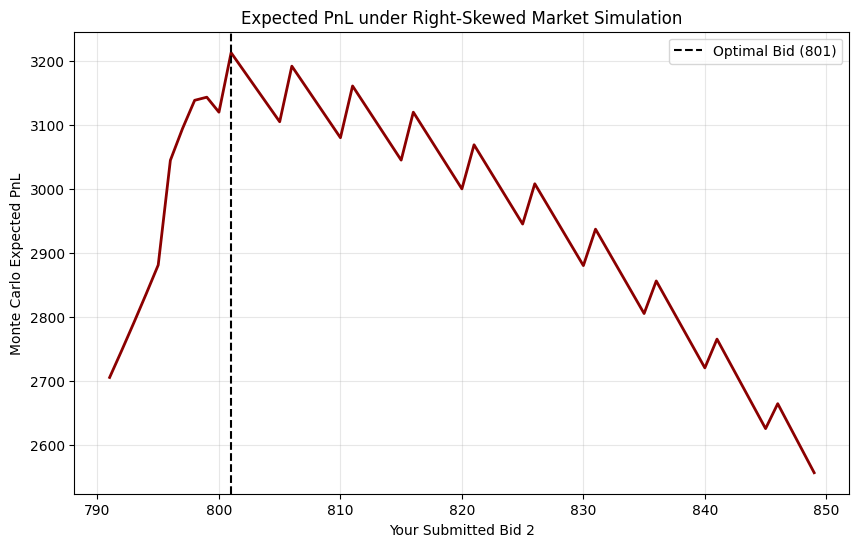

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def run_skewed_monte_carlo_optimization(demographics, num_simulations=10000, num_competitors=500):
    """
    Simulates the Prosperity environment thousands of times based on assumed competitor demographics
    to find the mathematically optimal Bid 2.
    """
    print(f"Running {num_simulations:,} simulations with {num_competitors} competitors each...")
    
    # Unpack demographics
    probs = [d['percent'] for d in demographics]
    
    # Step 1: Simulate the Competitor Pool
    # Randomly assign every competitor in every simulation to a behavioral bucket
    buckets = np.random.choice(len(probs), size=(num_simulations, num_competitors), p=probs)
    bids = np.zeros_like(buckets, dtype=float)
    
    # Fill the bids based on the bucket rules
    for i, demo in enumerate(demographics):
        mask = (buckets == i)
        count = np.sum(mask)
        # Randomly distribute their bids within their assigned range
        bids[mask] = np.random.randint(demo['min_bid'], demo['max_bid'] + 1, size=count)
        
    # Step 2: Calculate the true Global Average for every single simulated universe
    global_averages = np.mean(bids, axis=1)
    
    mean_simulated_avg = np.mean(global_averages)
    max_simulated_avg = np.max(global_averages)
    
    print(f"Average of all Simulated Global Averages: {mean_simulated_avg:.2f}")
    print(f"Absolute Highest Global Average hit in any simulation: {max_simulated_avg:.2f}")
    
    # Step 3: Optimize Your Bid against these 10,000 universes
    our_bids_to_test = np.arange(791, 850)
    expected_pnls = []
    
    reserve_prices = np.arange(670, 925, 5) # 670, 675 ... 920
    
    for our_bid in our_bids_to_test:
        # Base margin logic
        volume_won = np.sum(our_bid > reserve_prices)
        base_pnl = volume_won * (920 - our_bid)
        
        # Penalty Logic across all simulations simultaneously
        # True if we fell into the penalty in a given universe
        penalty_mask = our_bid <= global_averages 
        
        penalties = np.ones(num_simulations)
        penalties[penalty_mask] = ((920 - global_averages[penalty_mask]) / (920 - our_bid)) ** 3
        
        # Calculate final PnL for each universe and take the average (Expected Value)
        final_pnls = base_pnl * penalties
        expected_pnls.append(np.mean(final_pnls))
        
    # Find the peak
    optimal_idx = np.argmax(expected_pnls)
    optimal_bid = our_bids_to_test[optimal_idx]
    max_ev = expected_pnls[optimal_idx]
    
    print("\n--- FINAL OPTIMIZATION RESULTS ---")
    print(f"Optimal Bid to Submit: {optimal_bid}")
    print(f"Stochastic Expected PnL: {max_ev:,.2f}")
    
    return our_bids_to_test, expected_pnls, optimal_bid

if __name__ == "__main__":
    # --- TUNE YOUR MARKET ASSUMPTIONS HERE ---
    # Ensure the 'percent' values add up to exactly 1.0 (100%)
    market_demographics = [
        {'name': 'Level 0 (Rational Baseline)', 'percent': 0.30, 'min_bid': 791, 'max_bid': 791},
        {'name': 'Level 1 (The Snipers)',       'percent': 0.40, 'min_bid': 792, 'max_bid': 795},
        {'name': 'Level 2 (Over-Correctors)',   'percent': 0.20, 'min_bid': 796, 'max_bid': 810},
        {'name': 'Level 3 (The Paranoid Tail)', 'percent': 0.10, 'min_bid': 811, 'max_bid': 850}
    ]
    
    bids, pnls, best_bid = run_skewed_monte_carlo_optimization(market_demographics)
    
    # --- OPTIONAL: Plot the Expected Value Curve ---
    plt.figure(figsize=(10, 6))
    plt.plot(bids, pnls, linewidth=2, color='darkred')
    plt.axvline(x=best_bid, color='black', linestyle='--', label=f'Optimal Bid ({best_bid})')
    plt.title("Expected PnL under Right-Skewed Market Simulation")
    plt.xlabel("Your Submitted Bid 2")
    plt.ylabel("Monte Carlo Expected PnL")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()